<a href="https://colab.research.google.com/github/ANU-2524/US_Accidents_Dataset/blob/main/Anu_Squad84_US_Accidents_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print("Dataset path:", path)

Using Colab cache for faster access to the 'us-accidents' dataset.
Dataset path: /kaggle/input/us-accidents


In [ ]:
"""Description :
This dataset is about containing countrywide car accident dataset that
covers 49 states of the USA. The accident data were collected from February
2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data.
"""


'Description :\nThis dataset is about containing countrywide car accident dataset that\ncovers 49 states of the USA. The accident data were collected from February\n2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data.\n'

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [ ]:
file_path = os.path.join(path, "US_Accidents_March23.csv")

df = pd.read_csv(
    file_path,
    nrows=1000,        # Dataset is too much big , taking lot of time in loading. Best case , took only 1000 rows.
    low_memory=False # So that whole file get processed in once , and do not create error , if differnt data types used a column.
)

print(df.head())


    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

In [ ]:
print("Shape" , df.shape)
print("\n")
print("Columns " , df.columns)
print("\n")
print("Info " , df.info())
print("\n")
print("Describe " , df.describe())

Shape (1000, 46)


Columns  Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID           

In [ ]:
print(df.columns)

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')


In [ ]:
df.isnull().sum().sort_values(ascending=False)

print(df.head())

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

In [ ]:
"""
Feature Engineering :
"""

df["Start_Time"] = pd.to_datetime(df["Start_Time"])
df["Hour"] = df["Start_Time"].dt.hour
df["Day"] = df["Start_Time"].dt.day
df["Month"] = df["Start_Time"].dt.month
df["Weekday"] = df["Start_Time"].dt.day_name()
df["Is_Weekend"] = df["Weekday"].isin(["Saturday", "Sunday"])
df.groupby("Is_Weekend").size()
df["Weather_Condition"].value_counts().head(5)

print("Severity mean" , df["Severity"].mean())

Severity mean 2.371


In [ ]:
"""
Accidents by state (Top 10)
"""

df["State"].value_counts().head(10)

,count
State,
OH,726
CA,272
WV,2


In [ ]:
"""
Accidents at low visibility (< 2 miles)

"""

df[df["Visibility(mi)"] < 2].shape[0]

70

In [ ]:
"""
Most dangerous hour (high severity only)
"""

df[df["Severity"] >= 3].groupby("Hour").size().idxmax()

np.int32(7)

In [ ]:
"""
Total Number of Accidents
"""
print(len(df))

1000


In [ ]:
"""
Range of Severity (it tell us how the serious an accident was).
With range from 1 - 4.
"""
print(df["Severity"].min())
print(df["Severity"].max())

1
4


In [ ]:
KPI -> Key Performance Indicator.

SyntaxError: invalid syntax (ipython-input-3407974555.py, line 1)

In [ ]:
""" Count number of Unique state in the first 1000 rows of dataset.
"""

unique_states  = df["State"].unique()
print(len(unique_states))
# print(type(unique_states))

In [ ]:
"""
Top 15 Cities.
"""
def top_cities(df) :
  try :
    return df["City"].value_counts().head(15)
  except :
    print("Error occurred.")
    return None
top_cities(df)

,count
City,
Dayton,321
Columbus,170
Sacramento,32
San Jose,21
Miamisburg,16
Cleveland,16
Akron,15
Westerville,13
Dublin,12


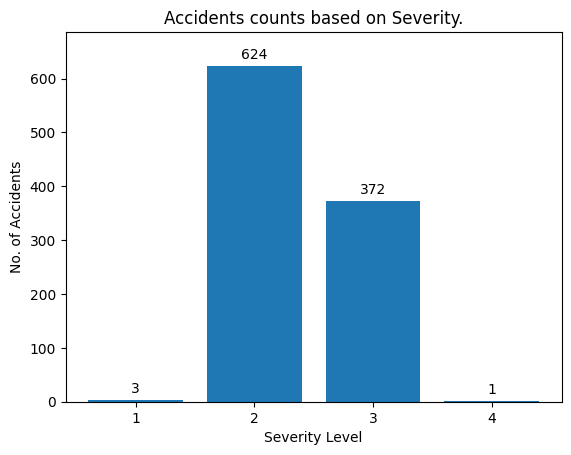

In [ ]:
"""
Severity wise Accidents count.
"""
def Severity_count(df) :
  try :
    count = df["Severity"].value_counts().sort_index()
    # accident_count =
    # count.plot(kind = "bar")
    bars = plt.bar(count.index.astype(str) , count.values)
    plt.bar_label(bars , padding = 3)
    plt.ylim(0, count.max() * 1.1)
    plt.title("Accidents counts based on Severity.")
    plt.xlabel("Severity Level")
    plt.ylabel("No. of Accidents")
    plt.show()

  except :
    print("Getting error in plotting graph.")

Severity_count(df)


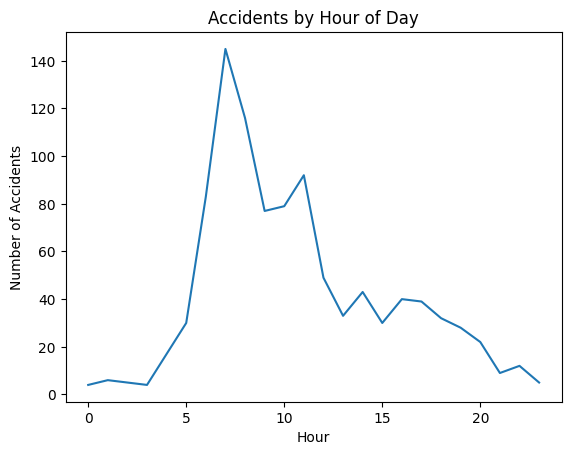

In [ ]:
"""
Plots number of accidents occurring at each hour of the day.
"""
def accidents(df):
    try:
        hourly = df["Hour"].value_counts().sort_index()
        hourly.plot(kind="line")
        plt.title("Accidents by Hour of Day")
        plt.xlabel("Hour")
        plt.ylabel("Number of Accidents")
        plt.show()
    except:
        print("Error plotting accidents by hour:", e)
accidents(df)


In [ ]:
df["State"]

,State
0,OH
1,OH
2,OH
3,OH
4,OH
...,...
995,CA
996,CA
997,CA
998,CA


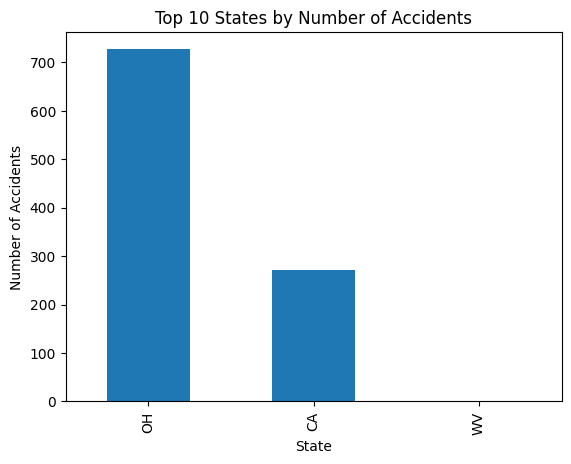

In [ ]:

"""
    Displays top 10 US states with the highest number of accidents.
"""
def top_10(df):

    try:
        top = df["State"].value_counts(ascending=False).head(10).plot(kind="bar")
        # top.plot(kind="bar")
        plt.title("Top 10 States by Number of Accidents")
        plt.xlabel("State")
        plt.ylabel("Number of Accidents")
        plt.show()
    except :
        print("Error occurred...",)

top_10(df)


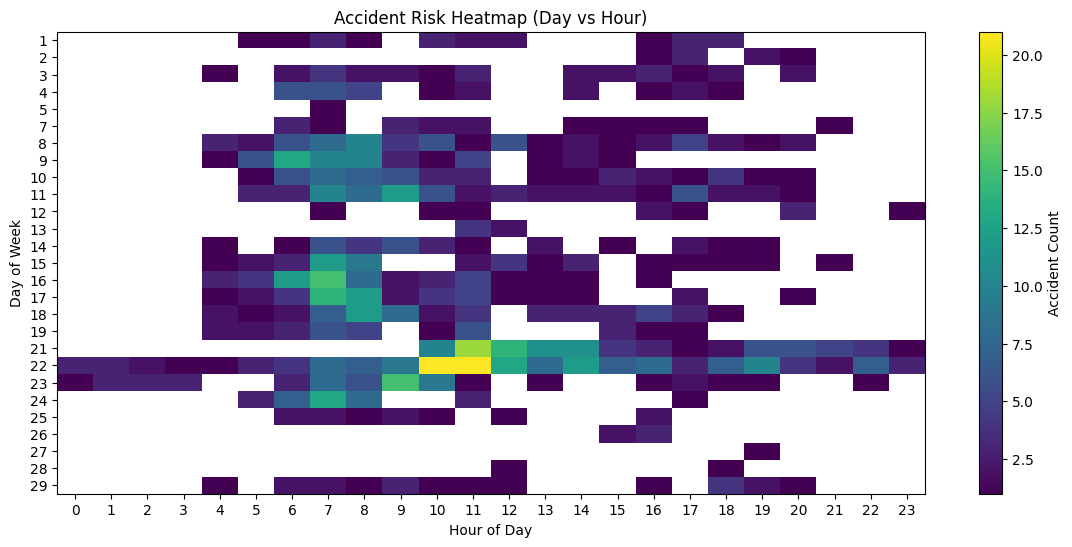

In [ ]:
def risk_heatmap(df):
    """Heatmap showing accident density by hour and day."""
    try:
        pivot = df.pivot_table(
            index="Day",
            columns="Hour",
            values="ID",
            aggfunc="count"
        )

        plt.figure(figsize=(14,6))
        plt.imshow(pivot, aspect="auto")
        plt.colorbar(label="Accident Count")
        plt.xticks(range(24))
        plt.yticks(range(len(pivot.index)), pivot.index)
        plt.title("Accident Risk Heatmap (Day vs Hour)")
        plt.xlabel("Hour of Day")
        plt.ylabel("Day of Week")
        plt.show()
    except :
        print(e)

risk_heatmap(df)

/tmp/ipython-input-4217018062.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df_clean.groupby(bins)["Severity"].mean()


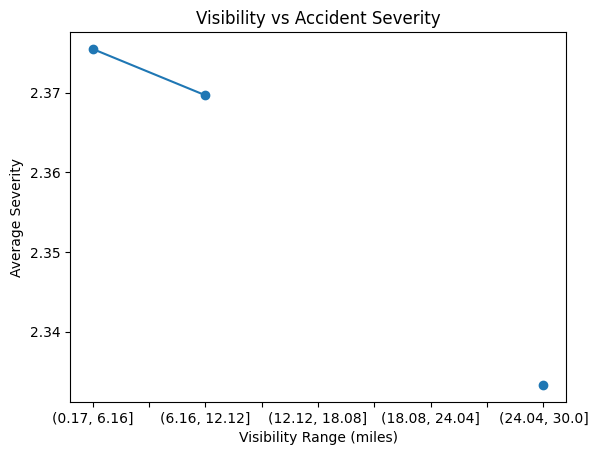

In [ ]:
def visibility_risk_curve(df):
    """Shows severity trend across visibility levels."""
    try:
        df_clean = df[df["Visibility(mi)"].notna()]

        bins = pd.cut(df_clean["Visibility(mi)"], bins=5)
        trend = df_clean.groupby(bins)["Severity"].mean()

        trend.plot(kind="line", marker="o")
        plt.title("Visibility vs Accident Severity")
        plt.xlabel("Visibility Range (miles)")
        plt.ylabel("Average Severity")
        plt.show()
    except:
        print(e)
visibility_risk_curve(df)

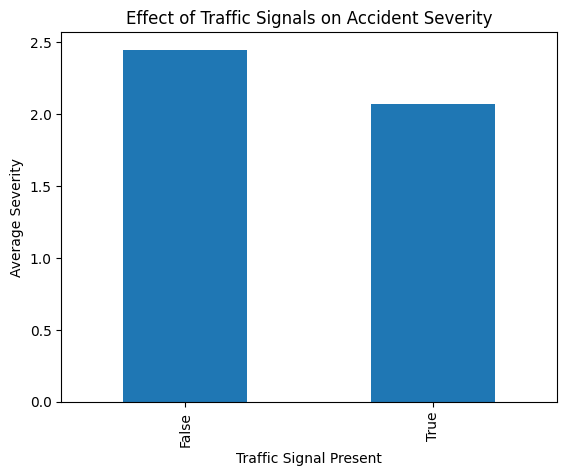

In [ ]:
def traffic_signal_effect(df):
    """Compares severity with and without traffic signals."""
    try:
        signal = df.groupby("Traffic_Signal")["Severity"].mean()

        signal.plot(kind="bar")
        plt.title("Effect of Traffic Signals on Accident Severity")
        plt.xlabel("Traffic Signal Present")
        plt.ylabel("Average Severity")
        plt.show()
    except Exception as e:
        print(e)
traffic_signal_effect(df)

In [ ]:
def severity_trend_yearly(df):
    """Yearly severity trend."""
    try:
        yearly = df.groupby("Year")["Severity"].mean()

        yearly.plot(marker="o")
        plt.title("Severity Trend Over Years")
        plt.xlabel("Year")
        plt.ylabel("Average Severity")
        plt.show()
    except Exception as e:
        print(e)
severity_trend_yearly(df)

'Year'


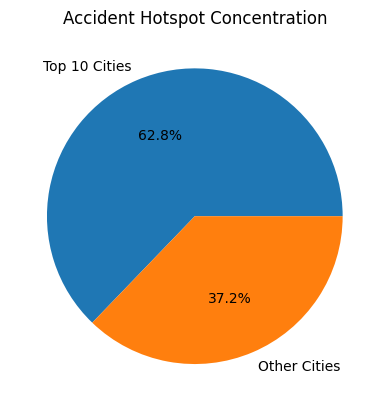

In [ ]:
def hotspot_concentration(df):
    """Measures how concentrated accidents are."""
    try:
        total = len(df)
        top10 = df["City"].value_counts().head(10).sum()

        labels = ["Top 10 Cities", "Other Cities"]
        values = [top10, total - top10]

        plt.pie(values, labels=labels, autopct="%1.1f%%")
        plt.title("Accident Hotspot Concentration")
        plt.show()
    except Exception as e:
        print(e)
hotspot_concentration(df)

In [ ]:
def severity_escalation_index(df):
    """Tracks % of high severity accidents over time."""
    try:
        high = df[df["Severity"] >= 3]
        trend = high.groupby("Year").size()

        trend.plot(kind="bar")
        plt.title("Severity Escalation Index (High Severity Accidents)")
        plt.xlabel("Year")
        plt.ylabel("Count")
        plt.show()
    except Exception as e:
        print(e)
severity_escalation_index(df)


'Year'
